In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import torch
import numpy as np
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from hdbscan import HDBSCAN


from common.data import DataWithLabels


In [ ]:
dataset = DataWithLabels.from_npz(r'data/monte_carlo_configurations.npz')

X              = dataset.x
Values         = dataset.values
Configurations = dataset.configurations
Energies       = dataset.energies
Labels         = dataset.labels

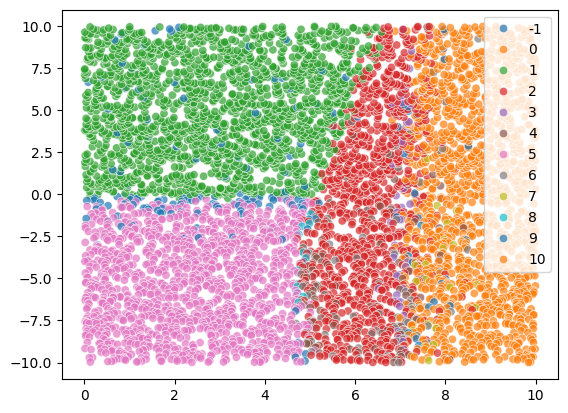

In [8]:
# Uncomment to get labels directly from the descriptor vector X.
from sklearn.cluster import DBSCAN

hd_label = DBSCAN(eps=0.01, metric='cosine').fit(X)
ax = sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=hd_label.labels_, palette='tab10', alpha=0.7)
Labels = hd_label.labels_

## Contrastive Learning

Epoch 1/100, Average Loss: 0.290431, Average Val Loss: 0.241984
Epoch 2/100, Average Loss: 0.217017, Average Val Loss: 0.110646
Epoch 3/100, Average Loss: 0.108168, Average Val Loss: 0.063203
Epoch 4/100, Average Loss: 0.079119, Average Val Loss: 0.053067
Epoch 5/100, Average Loss: 0.063988, Average Val Loss: 0.053765
Epoch 6/100, Average Loss: 0.057769, Average Val Loss: 0.046409
Epoch 7/100, Average Loss: 0.051521, Average Val Loss: 0.038432
Epoch 8/100, Average Loss: 0.048378, Average Val Loss: 0.037133
Epoch 9/100, Average Loss: 0.049890, Average Val Loss: 0.033292
Epoch 10/100, Average Loss: 0.046031, Average Val Loss: 0.030669
Epoch 11/100, Average Loss: 0.039425, Average Val Loss: 0.028629
Epoch 12/100, Average Loss: 0.040358, Average Val Loss: 0.028804
Epoch 13/100, Average Loss: 0.039047, Average Val Loss: 0.022013
Epoch 14/100, Average Loss: 0.036965, Average Val Loss: 0.020317
Epoch 15/100, Average Loss: 0.034308, Average Val Loss: 0.020103
Epoch 16/100, Average Loss: 0.0329

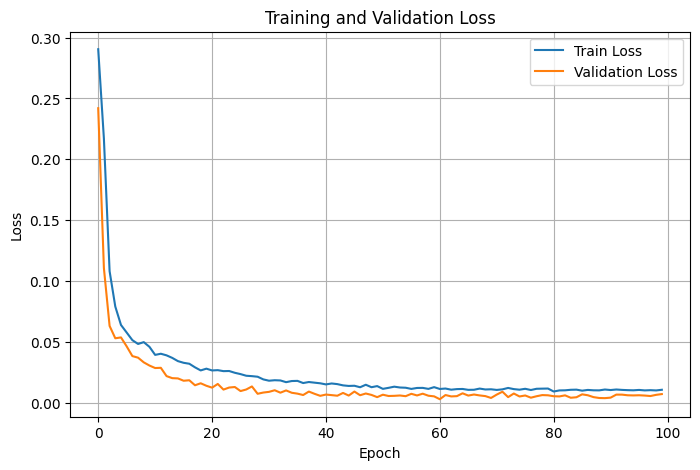

Embeddings shape: (6000, 2)


In [9]:
from contrastive_learning.model import SiameseNetwork, TrainConfig, train_model, get_embeddings
from contrastive_learning.dataset import make_balanced_train_test_dataset
from common.utils import plot_loss_curves

num_epochs = 100
warmup_epochs = max(1, int(0.05 * num_epochs))
EMBEDDING_SIZE = 2
train_loader, test_loader = make_balanced_train_test_dataset(
    Configurations, Labels, 
    batch_size=64, 
    train_ratio=0.8, 
    positive_ratio=0.5
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train = True
save_model = True
save_dir = Path('results')
save_dir.mkdir(exist_ok=True)
if train:
    model = SiameseNetwork(embedding_size=EMBEDDING_SIZE).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched1 = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=warmup_epochs)
    sched2 = CosineAnnealingLR(optimizer, T_max=(num_epochs - warmup_epochs))
    scheduler = SequentialLR(optimizer, schedulers=[sched1, sched2], milestones=[warmup_epochs])

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        test_loader=test_loader,
    )

    avg_loss, avg_val_loss = train_model(config, num_epochs=num_epochs, steps_per_epoch=50, margin=1.0)
    plot_loss_curves(avg_loss, avg_val_loss)
    if save_model:
        torch.save({
            'model_state_dict': model.state_dict(),
            'embedding_size': EMBEDDING_SIZE,
        }, save_dir / 'siamese_encoder.pt')
else:
    checkpoint = torch.load(save_dir / 'siamese_encoder.pt', map_location=device, weights_only=True)

    model = SiameseNetwork(embedding_size=checkpoint['embedding_size']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=None,
        scheduler=None,
        train_loader=None,
        test_loader=None,
    )

# Get embeddings for all configurations
all_embeddings = get_embeddings(config, Configurations)
print(f"Embeddings shape: {all_embeddings.shape}")

## Clustering

here, we shall cluster samples in the embedding space and compare to the original clustering.

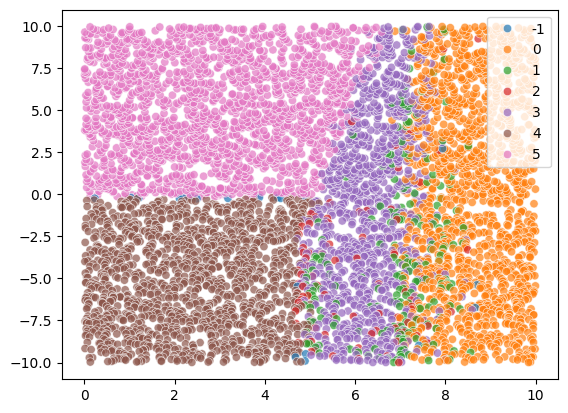

In [10]:
from hdbscan import HDBSCAN

hd_contr = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.005, cluster_selection_method='eom').fit(all_embeddings)
Labels_contr = hd_contr.labels_

ax = sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=Labels_contr, palette='tab10', alpha=0.7)

In [ ]:
data_grad = DataWithLabels.from_npz('data/optimized_configurations.npz')
embeddings_grad = get_embeddings(config, data_grad.configurations)

<Axes: >

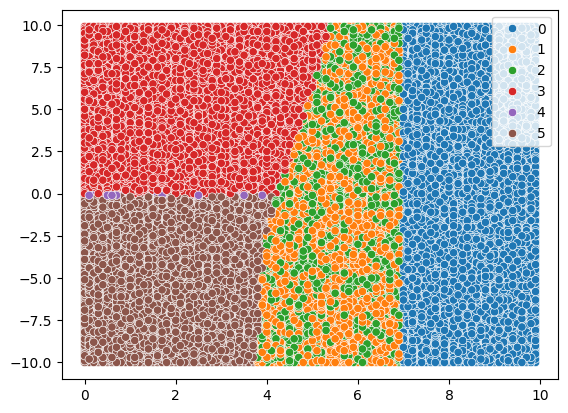

In [12]:
hd_grad = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.1, cluster_selection_method='eom').fit(embeddings_grad)
Labels_grad = hd_grad.labels_

Values_grad = data_grad.values
sns.scatterplot(x=Values_grad[:, 1], y=Values_grad[:, 0], hue=Labels_grad, palette='tab10')

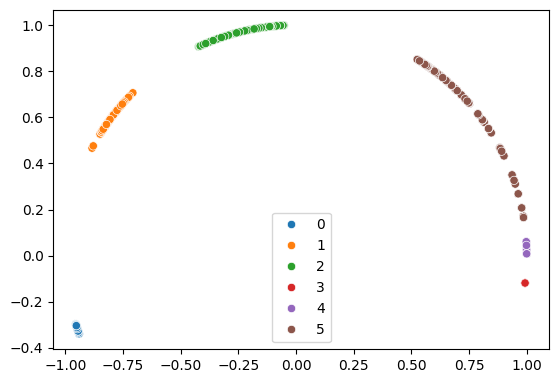

In [13]:
ax = sns.scatterplot(x=embeddings_grad[:, 0], y=embeddings_grad[:, 1], hue=Labels_grad, palette='tab10')
ax.set_aspect('equal')